<a href="https://colab.research.google.com/github/Abhiyuday07/TCS_stock_Price/blob/main/TCS_stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

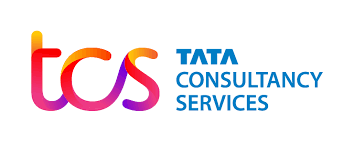

In [ ]:
import yfinance as yf

In [ ]:
df=yf.download("AAPL",start="2025-01-01",end="2026-04-29")

/tmp/ipykernel_3929/3103040652.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download("AAPL",start="2025-01-01",end="2026-04-29")
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.525162,247.746638,240.506192,247.577549,55740700
2025-01-03,242.037827,242.853364,240.575812,242.037827,40244100
2025-01-06,243.668900,245.986242,241.878676,242.982646,45045600
2025-01-07,240.894073,244.215924,240.038745,241.659879,40856000
2025-01-08,241.381409,242.385931,238.745812,240.605648,37628900
...,...,...,...,...,...
2026-04-22,273.170013,273.739990,266.869995,267.820007,43249200
2026-04-23,273.429993,275.769989,271.649994,275.049988,33399600


In [ ]:
df=yf.download("TCS.NS",start="2025-01-01",end="2026-04-29")
df


/tmp/ipykernel_3929/3037171585.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download("TCS.NS",start="2025-01-01",end="2026-04-29")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2025-01-01,3903.252930,3923.706512,3877.626168,3886.120842,763161
2025-01-02,3963.332275,3970.213473,3888.540966,3910.418242,1720835
2025-01-03,3891.340820,3967.319010,3884.127566,3967.319010,1791953
2025-01-06,3886.690430,3938.560333,3859.545197,3896.656303,2085593
2025-01-07,3823.383057,3929.733193,3807.485118,3905.625367,2669054
...,...,...,...,...,...
2026-04-22,2538.500000,2580.000000,2503.600098,2580.000000,5232045
2026-04-23,2521.800049,2559.500000,2516.300049,2529.000000,2509050


In [ ]:
display(df[['Open', 'Close']])

Price,Open,Close
Ticker,TCS.NS,TCS.NS
Date,,
2025-01-01,3886.120842,3903.252930
2025-01-02,3910.418242,3963.332275
2025-01-03,3967.319010,3891.340820
2025-01-06,3896.656303,3886.690430
2025-01-07,3905.625367,3823.383057
...,...,...
2026-04-22,2580.000000,2538.500000
2026-04-23,2529.000000,2521.800049


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

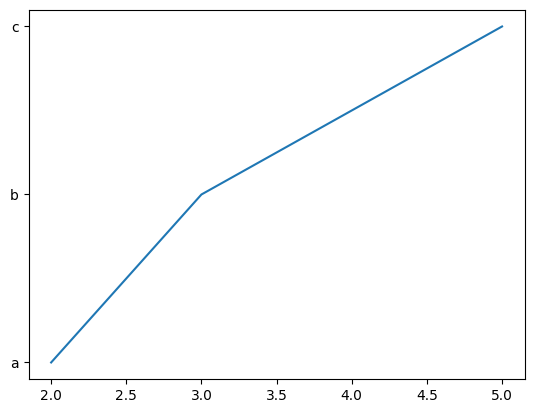

In [ ]:
x=(2,3,5)
y=("a","b","c")
plt.plot(x,y)
plt.show()

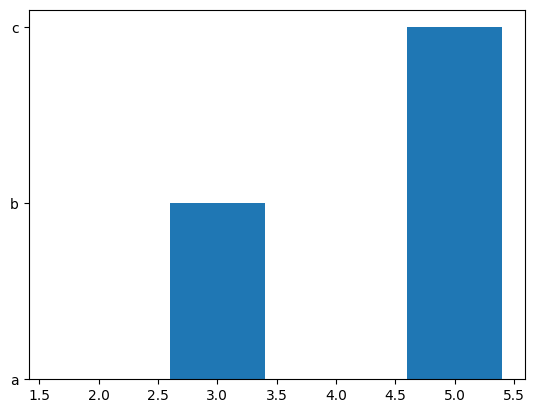

In [ ]:
x=(2,3,5)
y=("a","b","c")
plt.bar(x,y)
plt.show()

In [ ]:
display(df[['Open', 'Close']])

Price,Open,Close
Ticker,TCS.NS,TCS.NS
Date,,
2025-01-01,3886.120842,3903.252930
2025-01-02,3910.418242,3963.332275
2025-01-03,3967.319010,3891.340820
2025-01-06,3896.656303,3886.690430
2025-01-07,3905.625367,3823.383057
...,...,...
2026-04-22,2580.000000,2538.500000
2026-04-23,2529.000000,2521.800049


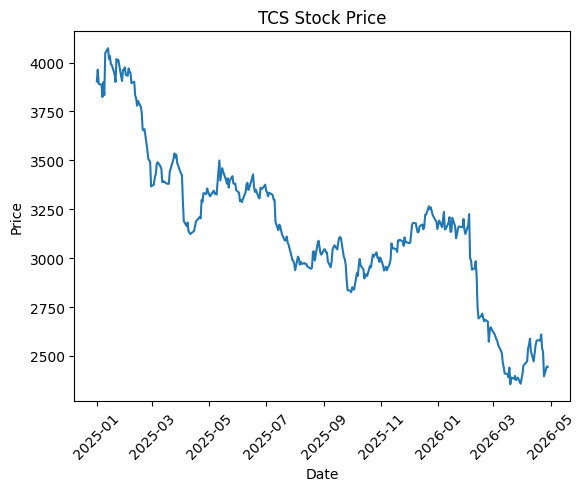

In [ ]:
plt.plot(df['Close'])
plt.title('TCS Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()


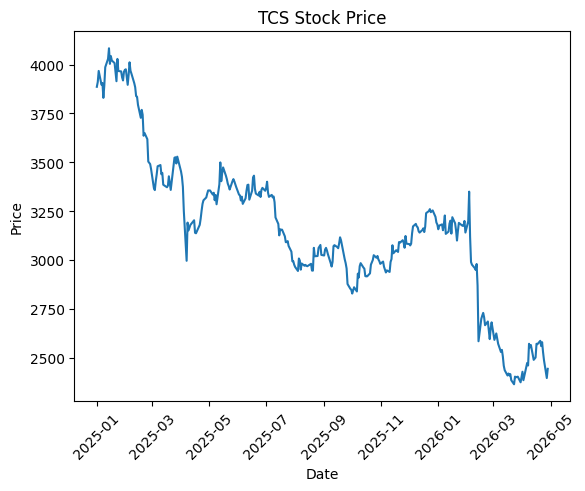

In [ ]:
plt.plot(df['Open'])
plt.title('TCS Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

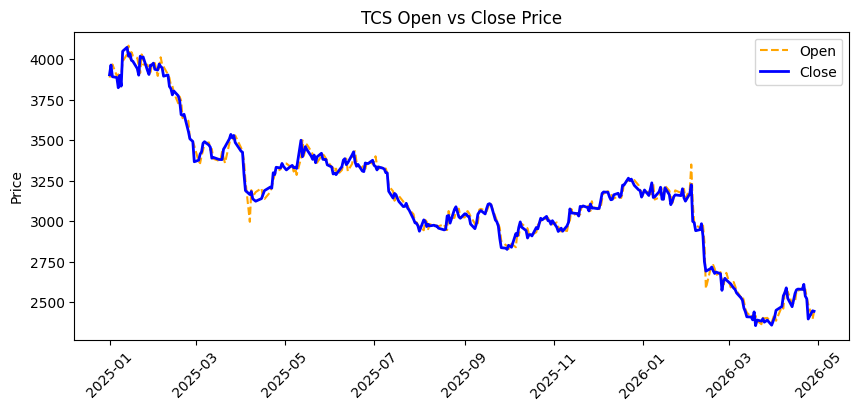

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df['Open'], label='Open', linestyle='--', color='orange')
plt.plot(df.index, df['Close'], label='Close', color='blue', linewidth=2)
plt.title('TCS Open vs Close Price')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.show()

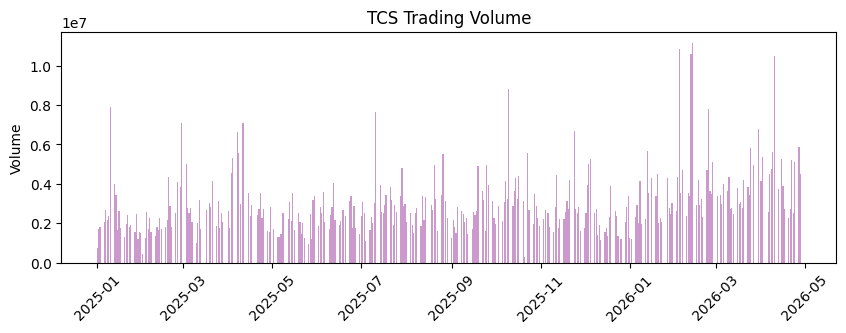

In [ ]:
plt.figure(figsize=(10, 3))

# We select only the first column if multiple 'Volume' columns exist
vol = df['Volume']
if len(vol.shape) > 1:
    vol = vol.iloc[:, 0]

# Convert to numeric and plot
plt.bar(df.index, pd.to_numeric(vol, errors='coerce'), color='purple', alpha=0.4)

plt.title('TCS Trading Volume')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.show()

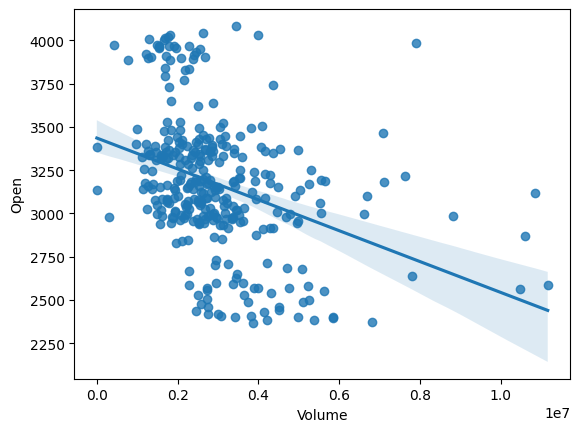

In [ ]:
sns.regplot(x='Volume',y='Open',data=df)
plt.xlabel("Volume")
plt.ylabel("Open")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Prepare data
df['Day_Index'] = np.arange(len(df))
X = df[['Day_Index']].values
y_open = df['Open'].values
y_close = df['Close'].values

# 2. Train models
model_open = LinearRegression().fit(X, y_open)
model_close = LinearRegression().fit(X, y_close)

# 3. Predict for tomorrow
tomorrow_index = np.array([[len(df)]])
pred_open = model_open.predict(tomorrow_index)
pred_close = model_close.predict(tomorrow_index)

# 4. Print results (Fixed using .item() to convert array to scalar)
print(f"Predicted Open for Tomorrow: {pred_open.item():.2f}")
print(f"Predicted Close for Tomorrow: {pred_close.item():.2f}")

Predicted Open for Tomorrow: 2585.94
Predicted Close for Tomorrow: 2579.39


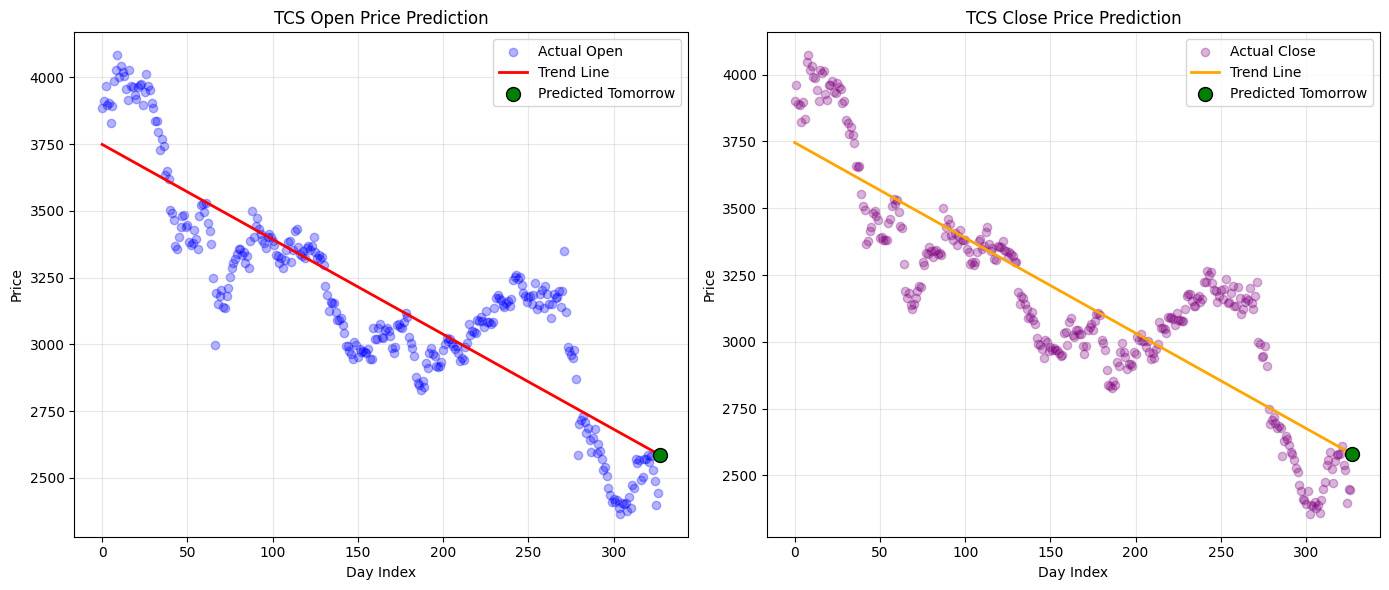

In [ ]:
import matplotlib.pyplot as plt

# Create indices for plotting
history_idx = np.arange(len(df))
tomorrow_idx = len(df)

plt.figure(figsize=(14, 6))

# --- Graph 1: Open Price Prediction ---
plt.subplot(1, 2, 1)
plt.scatter(history_idx, df['Open'], color='blue', alpha=0.3, label='Actual Open')
# Plot the regression line
plt.plot(history_idx, model_open.predict(X), color='red', linewidth=2, label='Trend Line')
# Plot the "Tomorrow" prediction point
plt.scatter(tomorrow_idx, pred_open.item(), color='green', s=100, edgecolors='black', label='Predicted Tomorrow', zorder=5)

plt.title('TCS Open Price Prediction')
plt.xlabel('Day Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Graph 2: Close Price Prediction ---
plt.subplot(1, 2, 2)
plt.scatter(history_idx, df['Close'], color='purple', alpha=0.3, label='Actual Close')
# Plot the regression line
plt.plot(history_idx, model_close.predict(X), color='orange', linewidth=2, label='Trend Line')
# Plot the "Tomorrow" prediction point
plt.scatter(tomorrow_idx, pred_close.item(), color='green', s=100, edgecolors='black', label='Predicted Tomorrow', zorder=5)

plt.title('TCS Close Price Prediction')
plt.xlabel('Day Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()